## 集成学习 ##

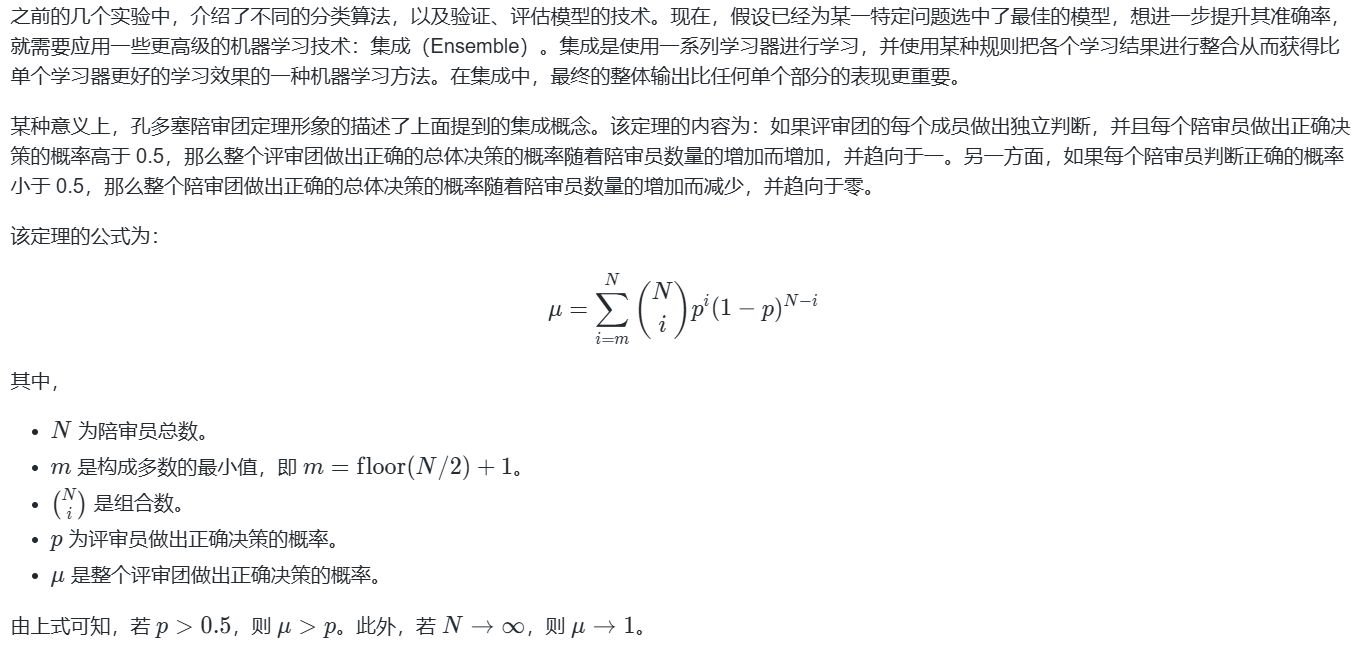

## Bootstrapping ##
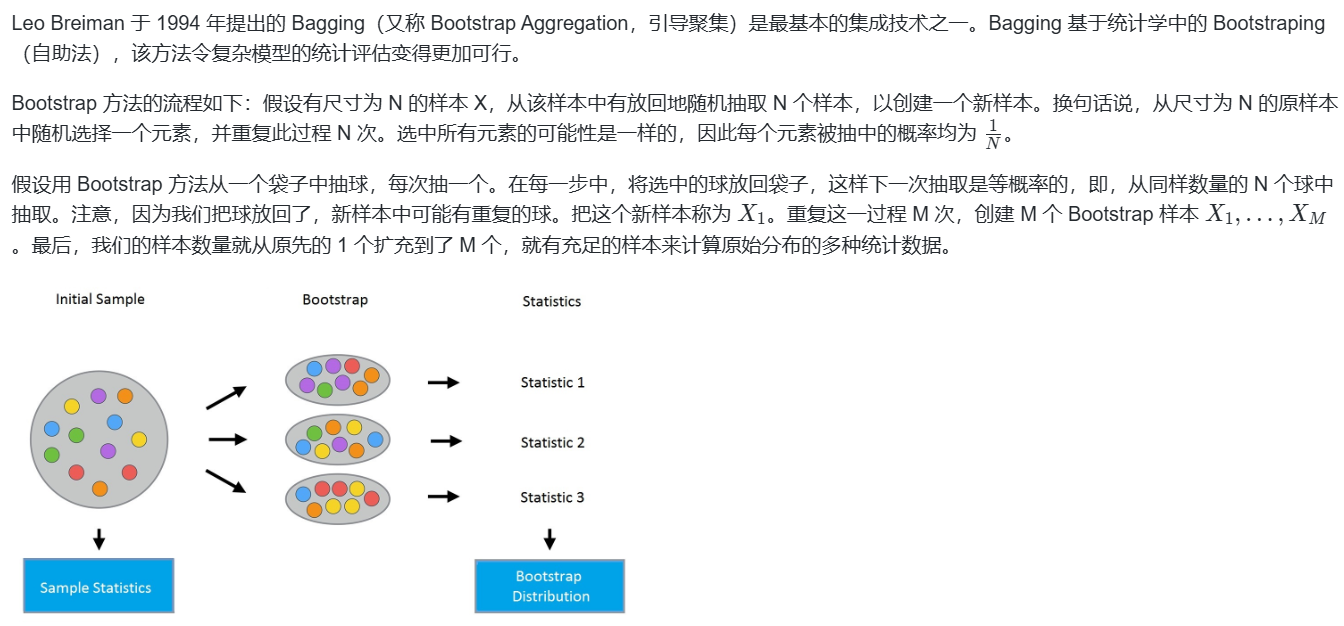

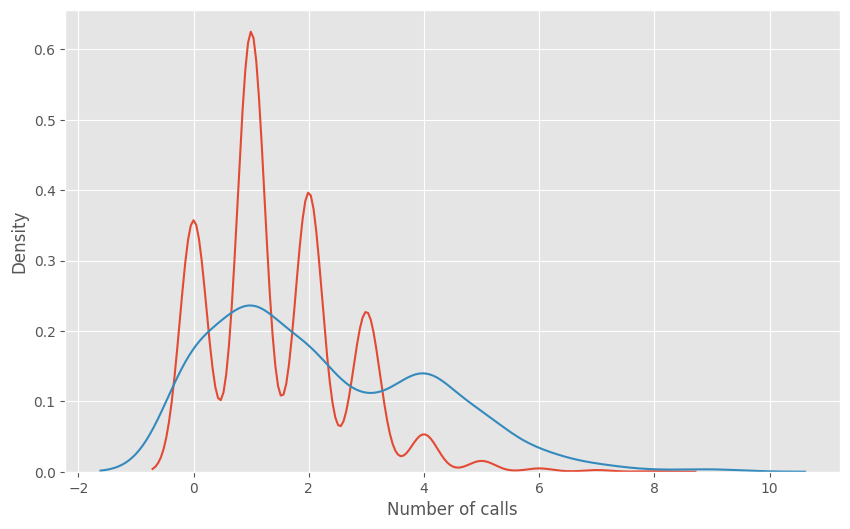

In [1]:
import warnings
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = 10, 6
%matplotlib inline
warnings.filterwarnings('ignore')
telecom_data = pd.read_csv(
    'https://labfile.oss.aliyuncs.com/courses/1283/telecom_churn.csv')

fig = sns.kdeplot(telecom_data[telecom_data['Churn']
                               == False]['Customer service calls'], label='Loyal')
fig = sns.kdeplot(telecom_data[telecom_data['Churn']
                               == True]['Customer service calls'], label='Churn')
fig.set(xlabel='Number of calls', ylabel='Density')

plt.show()


上图表明，相比那些逐渐离网的客户，忠实客户呼叫客服的次数更少。估计每组客户的平均呼叫客服数可能很有用，但由于该数据集很小，如果直接计算原样本的均值，得到的估计可能较差。因此可以应用 Bootstrap 方法，基于原样本生成 1000 个新 Bootstrap 样本，然后计算均值的区间估计。


In [2]:
def get_bootstrap_samples(data, n_samples):
    indices = np.random.randint(0, len(data), (n_samples, len(data)))
    samples = data[indices]
    return samples


def stat_intervals(stat, alpha):
    boundaries = np.percentile(
        stat, [100 * alpha / 2., 100 * (1 - alpha / 2.)])
    return boundaries

loyal_calls = telecom_data.loc[telecom_data['Churn'] == False,
                               'Customer service calls'].values
churn_calls = telecom_data.loc[telecom_data['Churn'] == True,
                               'Customer service calls'].values

np.random.seed(0)

loyal_mean_scores = [np.mean(sample)
                     for sample in get_bootstrap_samples(loyal_calls, 1000)]
churn_mean_scores = [np.mean(sample)
                     for sample in get_bootstrap_samples(churn_calls, 1000)]


print("Service calls from loyal: mean interval",
      stat_intervals(loyal_mean_scores, 0.05))
print("Service calls from churn: mean interval",
      stat_intervals(churn_mean_scores, 0.05))


Service calls from loyal: mean interval [1.4077193  1.49473684]
Service calls from churn: mean interval [2.0621118  2.39761905]


上述结果表明，有 95% 的概率，忠实客户平均呼叫客服的次数在 1.4 到 1.49 之间，而离网客户平均呼叫客服的次数在 2.06 到 2.40 之间。另外，可以注意到忠实客户的区间更窄，这是合理的，因为相比多次呼叫客服的离网客户，忠实客户呼叫客服的次数更少（0、1、2 次）



## Bagging ##
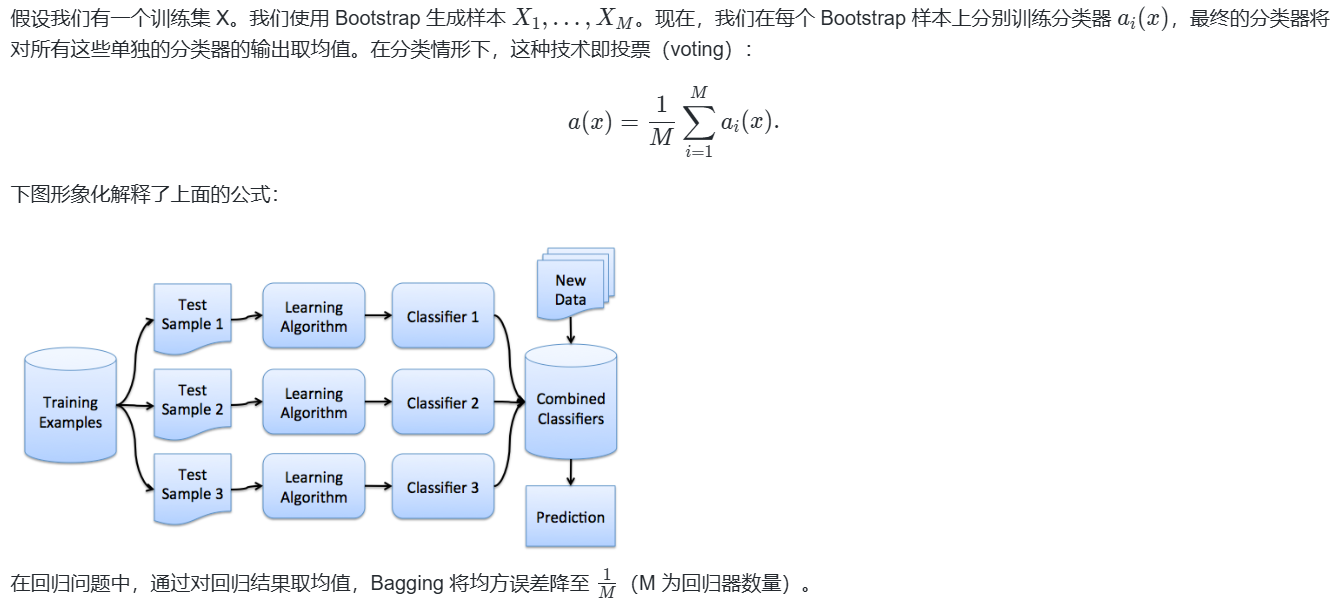
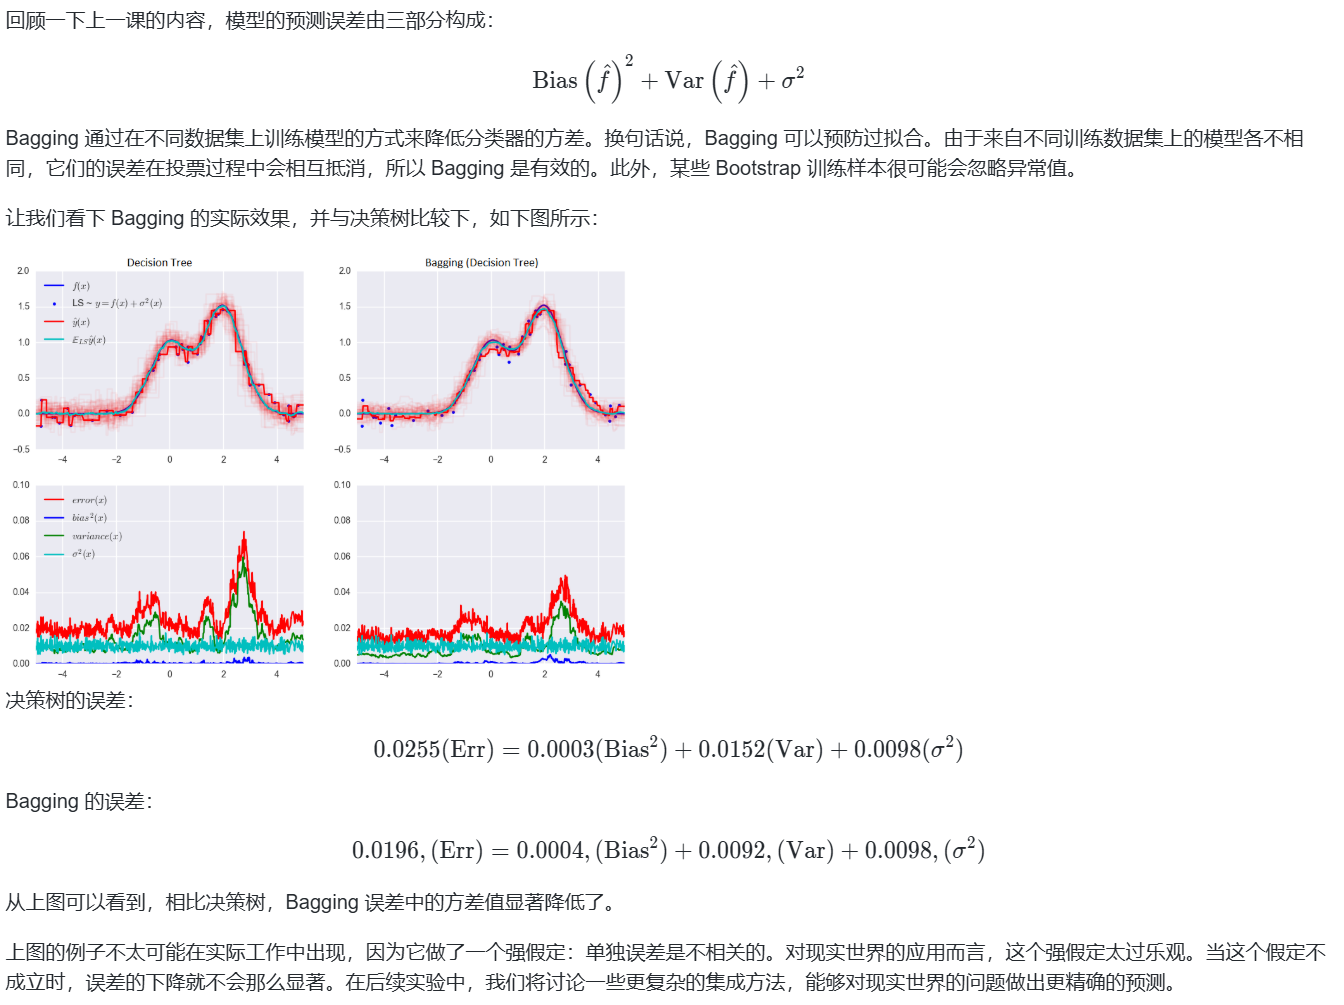



## OOB Error ##

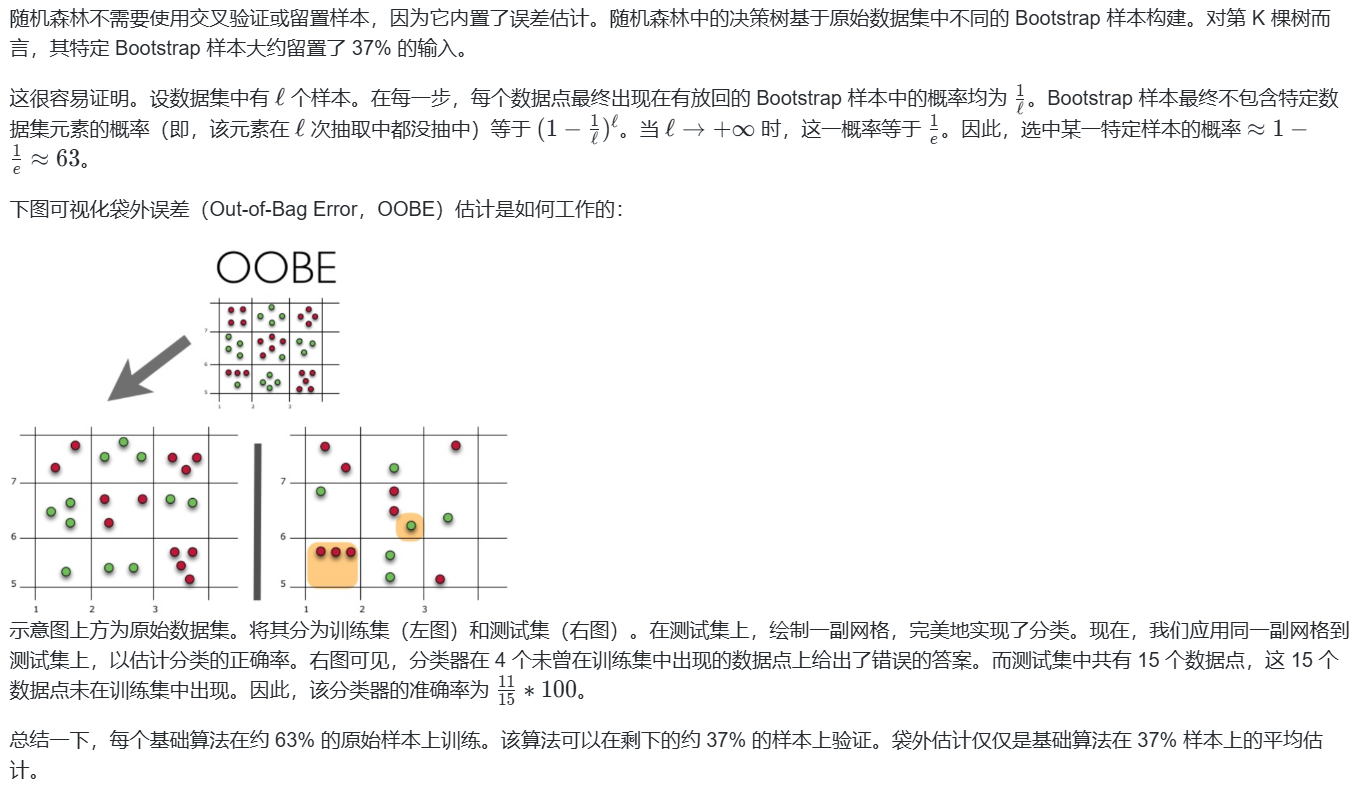


## 随机森林 ##
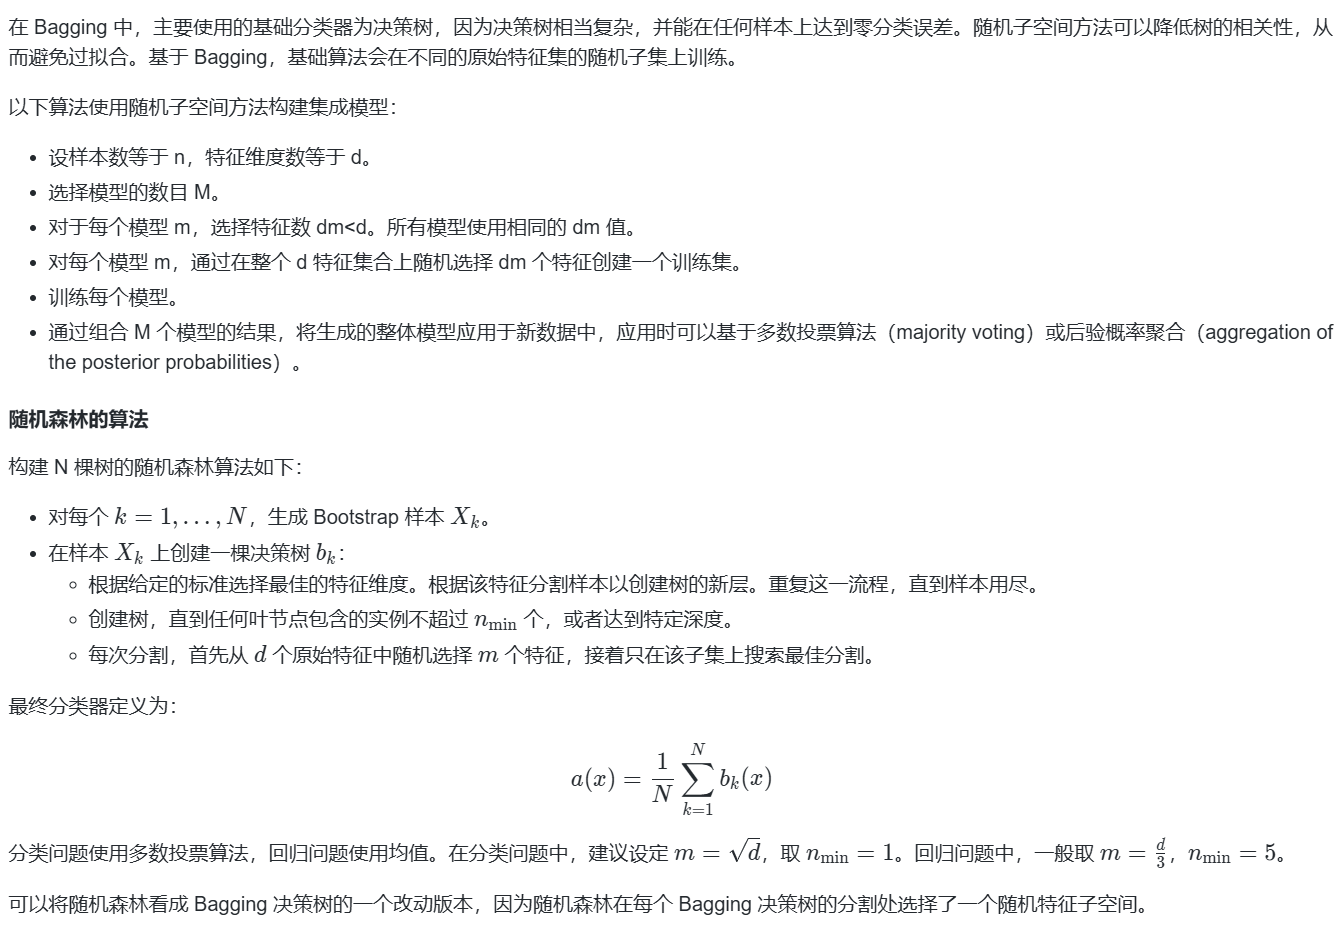



## 随机森林，Bagging与决策树 ##


In [10]:

from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, BaggingRegressor
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
import seaborn as sns
from matplotlib import pyplot as plt

# Disable warnings in Anaconda
import warnings
import numpy as np
warnings.filterwarnings('ignore')

%matplotlib inline
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = 10, 6


n_train = 150
n_test = 1000
noise = 0.1


In [11]:
# 生成数据
def f(x):
    x = x.ravel()
    return np.exp(-x ** 2) + 1.5 * np.exp(-(x - 2) ** 2)


def generate(n_samples, noise):
    X = np.random.rand(n_samples) * 10 - 5
    X = np.sort(X).ravel()
    y = np.exp(-X ** 2) + 1.5 * np.exp(-(X - 2) ** 2)\
        + np.random.normal(0.0, noise, n_samples)
    X = X.reshape((n_samples, 1))

    return X, y


X_train, y_train = generate(n_samples=n_train, noise=noise)
X_test, y_test = generate(n_samples=n_test, noise=noise)


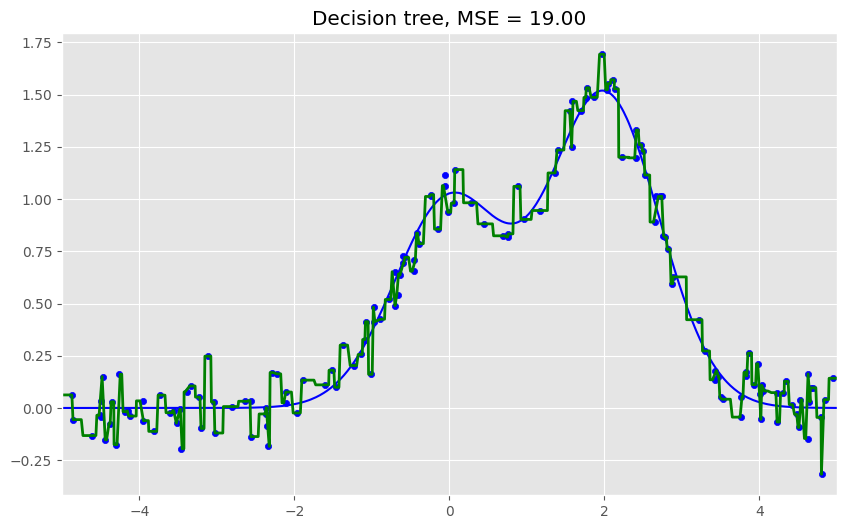

In [12]:
# 单棵决策树回归
dtree = DecisionTreeRegressor().fit(X_train, y_train)
d_predict = dtree.predict(X_test)

plt.figure(figsize=(10, 6))
plt.plot(X_test, f(X_test), "b")
plt.scatter(X_train, y_train, c="b", s=20)
plt.plot(X_test, d_predict, "g", lw=2)
plt.xlim([-5, 5])
plt.title("Decision tree, MSE = %.2f"
          % np.sum((y_test - d_predict) ** 2))
plt.show()


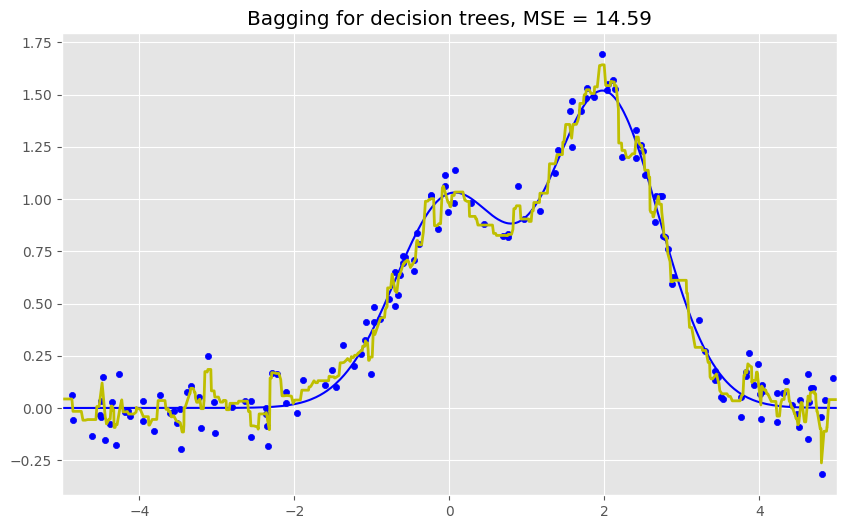

In [13]:
# Bagging
bdt = BaggingRegressor(DecisionTreeRegressor()).fit(X_train, y_train)
bdt_predict = bdt.predict(X_test)

plt.figure(figsize=(10, 6))
plt.plot(X_test, f(X_test), "b")
plt.scatter(X_train, y_train, c="b", s=20)
plt.plot(X_test, bdt_predict, "y", lw=2)
plt.xlim([-5, 5])
plt.title("Bagging for decision trees, MSE = %.2f" %
          np.sum((y_test - bdt_predict) ** 2))
plt.show()


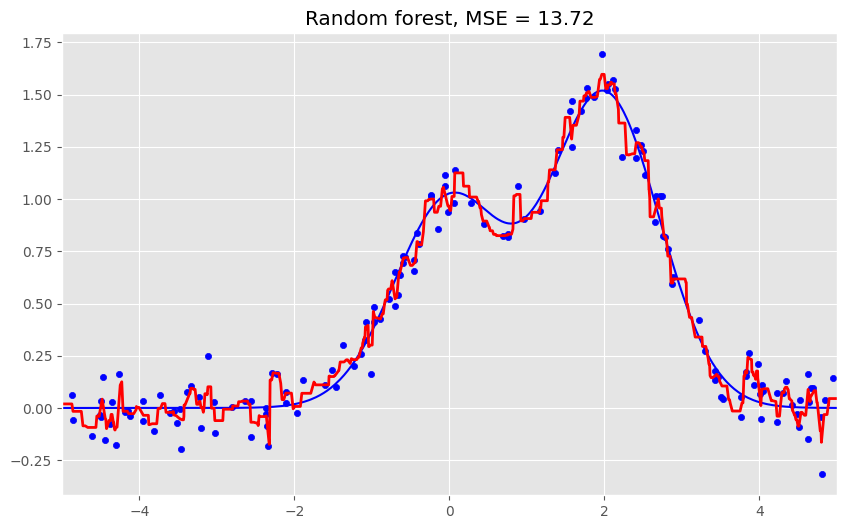

In [14]:
# 随机森林
rf = RandomForestRegressor(n_estimators=10).fit(X_train, y_train)
rf_predict = rf.predict(X_test)

plt.figure(figsize=(10, 6))
plt.plot(X_test, f(X_test), "b")
plt.scatter(X_train, y_train, c="b", s=20)
plt.plot(X_test, rf_predict, "r", lw=2)
plt.xlim([-5, 5])
plt.title("Random forest, MSE = %.2f" % np.sum((y_test - rf_predict) ** 2))
plt.show()


从上面 3 张图像和 MSE 值可以看到，10 树随机森林比单棵决策树和 10 树 Bagging 的表现要好，当然随机森林在这个例子上不稳定，多次运行结果表明随机森林和 Bagging 决策树互有胜负。随机森林和 Bagging 的主要差别在于，前者分割的最佳特征是从一个随机特征子空间中选取的，而后者在分割时将考虑所有特征。  
  
  
接下来，我们将查看随机森林和 Bagging 在分类问题上的表现。

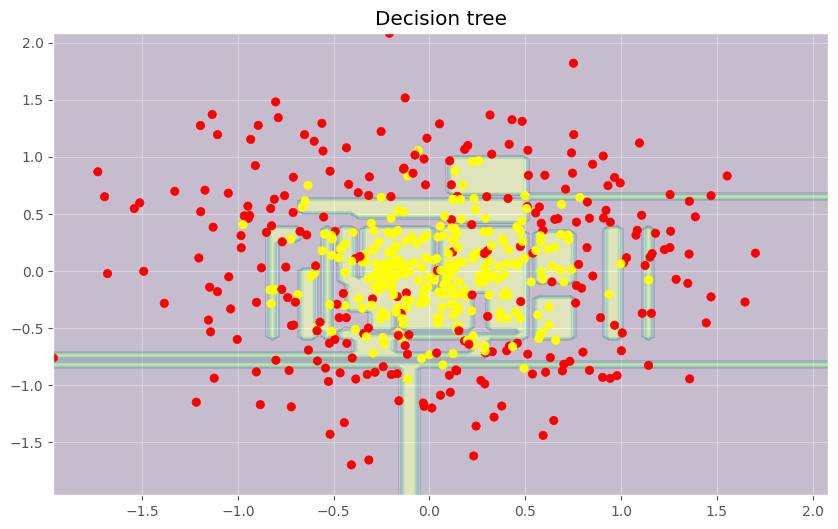

In [15]:
np.random.seed(42)
X, y = make_circles(n_samples=500, factor=0.1, noise=0.35, random_state=42)
X_train_circles, X_test_circles, y_train_circles, y_test_circles = train_test_split(
    X, y, test_size=0.2)

dtree = DecisionTreeClassifier(random_state=42)
dtree.fit(X_train_circles, y_train_circles)

x_range = np.linspace(X.min(), X.max(), 100)
xx1, xx2 = np.meshgrid(x_range, x_range)
y_hat = dtree.predict(np.c_[xx1.ravel(), xx2.ravel()])
y_hat = y_hat.reshape(xx1.shape)
plt.contourf(xx1, xx2, y_hat, alpha=0.2)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='autumn')
plt.title("Decision tree")
plt.show()


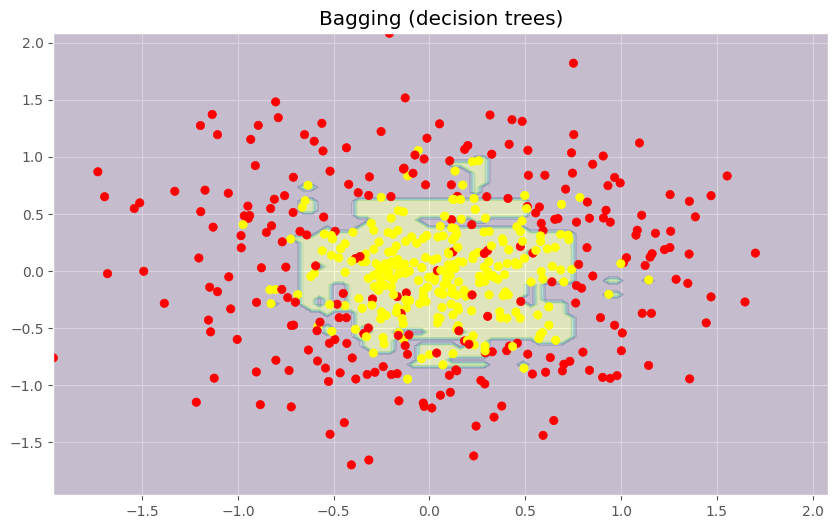

In [16]:

b_dtree = BaggingClassifier(
    DecisionTreeClassifier(), n_estimators=300, random_state=42)
b_dtree.fit(X_train_circles, y_train_circles)

x_range = np.linspace(X.min(), X.max(), 100)
xx1, xx2 = np.meshgrid(x_range, x_range)
y_hat = b_dtree.predict(np.c_[xx1.ravel(), xx2.ravel()])
y_hat = y_hat.reshape(xx1.shape)
plt.contourf(xx1, xx2, y_hat, alpha=0.2)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='autumn')
plt.title("Bagging (decision trees)")
plt.show()


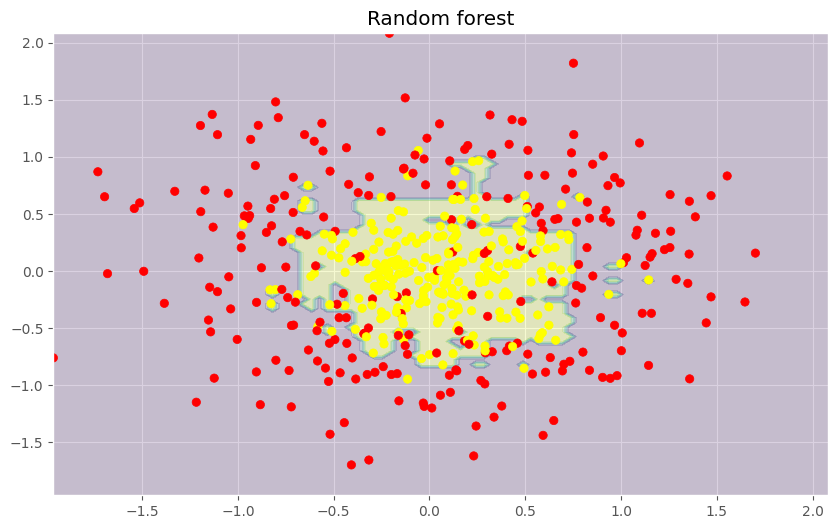

In [17]:

rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X_train_circles, y_train_circles)

x_range = np.linspace(X.min(), X.max(), 100)
xx1, xx2 = np.meshgrid(x_range, x_range)
y_hat = rf.predict(np.c_[xx1.ravel(), xx2.ravel()])
y_hat = y_hat.reshape(xx1.shape)
plt.contourf(xx1, xx2, y_hat, alpha=0.2)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='autumn')
plt.title("Random forest")
plt.show()

上图显示了决策树形成的边界凹凸不平，有大量锐角，这暗示出现过拟合现象。相反，随机森林和 Bagging 的边界相当平滑，没有明显的过拟合的迹象。

## 随机森林的参数 ## 
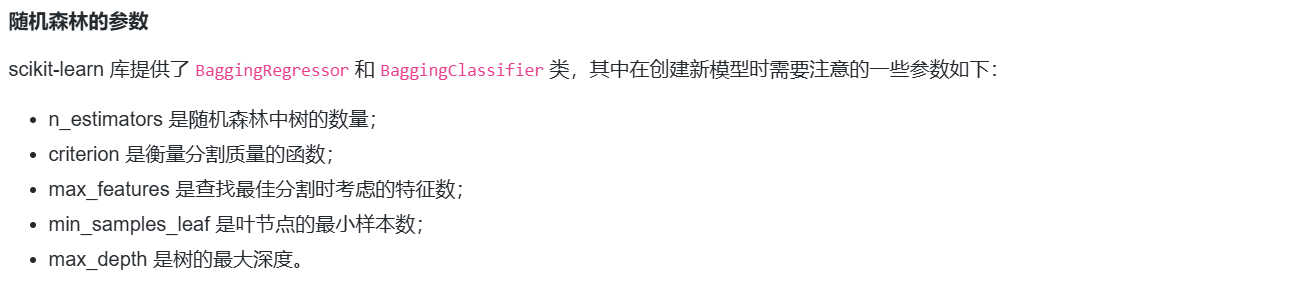

## 随机森林在现实问题中的应用 ##
使用之前运营商的客户离网数据集作为例子。这是一个分类问题，使用准确率评估模型

In [ ]:
import pandas as pd
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score

df = pd.read_csv(
    "https://labfile.oss.aliyuncs.com/courses/1283/telecom_churn.csv")

# 选择数值型特征
cols = []
for i in df.columns:
    if (df[i].dtype == "float64") or (df[i].dtype == 'int64'):
        cols.append(i)

X, y = df[cols].copy(), np.asarray(df["Churn"], dtype='int8')

# 交叉验证
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 随机森林分类器
rfc = RandomForestClassifier(random_state=42, n_jobs=-1, oob_score=True)

results = cross_val_score(rfc, X, y, cv=skf)

print("CV accuracy score: {:.2f}%".format(results.mean()*100))

CV accuracy score: 92.50%


得到了 92.50% 的准确率作为基线，现在，尝试改进结果，同时查看一下基本参数变化时的学习曲线。首先，从改进树的数量开始，初始化 K 折交叉验证。

In [24]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

train_acc = []
test_acc = []
temp_train_acc = []
temp_test_acc = []

trees_grid = [5, 10, 15, 20, 30, 50, 75, 100]

for ntrees in trees_grid:
    rfc = RandomForestClassifier(
        n_estimators=ntrees, random_state=42, n_jobs=-1, oob_score=True)
    temp_train_acc = []
    temp_test_acc = []
    for train_index, test_index in skf.split(X, y):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y[train_index], y[test_index]
        rfc.fit(X_train, y_train)
        temp_train_acc.append(rfc.score(X_train, y_train))
        temp_test_acc.append(rfc.score(X_test, y_test))
    train_acc.append(temp_train_acc)
    test_acc.append(temp_test_acc)

train_acc, test_acc = np.asarray(train_acc), np.asarray(test_acc)
print("Best accuracy on CV is {:.2f}% with {} trees".format(max(test_acc.mean(axis=1))*100,
                                                            trees_grid[np.argmax(test_acc.mean(axis=1))]))

Best accuracy on CV is 92.50% with 100 trees


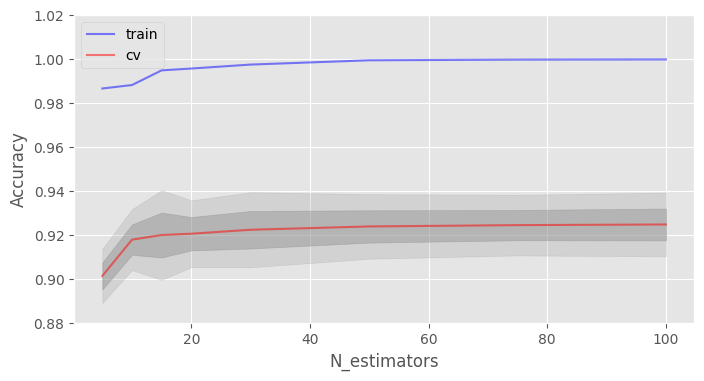

In [26]:
plt.style.use('ggplot')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(trees_grid, train_acc.mean(axis=1),alpha=0.5, color='blue', label='train')
ax.plot(trees_grid, test_acc.mean(axis=1), alpha=0.5, color='red', label='cv')
ax.fill_between(trees_grid, test_acc.mean(axis=1) - test_acc.std(axis=1),
                test_acc.mean(axis=1) + test_acc.std(axis=1), color='#888888', alpha=0.4)
ax.fill_between(trees_grid, test_acc.mean(axis=1) - 2*test_acc.std(axis=1),
                test_acc.mean(axis=1) + 2*test_acc.std(axis=1), color='#888888', alpha=0.2)
ax.legend(loc='best')
ax.set_ylim([0.88, 1.02])
ax.set_ylabel("Accuracy")
ax.set_xlabel("N_estimators")
plt.show()

上图表明，当树的数量增加到一定值时，测试集上的准确率不再提升，同时训练集上的准确率达到了 100%，这意味着出现过拟合。

为了避免过拟合，需要给模型加上正则化参数。下面将树的数目固定为 100，然后看看不同的 max_depth 效果如何

Best accuracy on CV is 92.44% with 24 max_depth


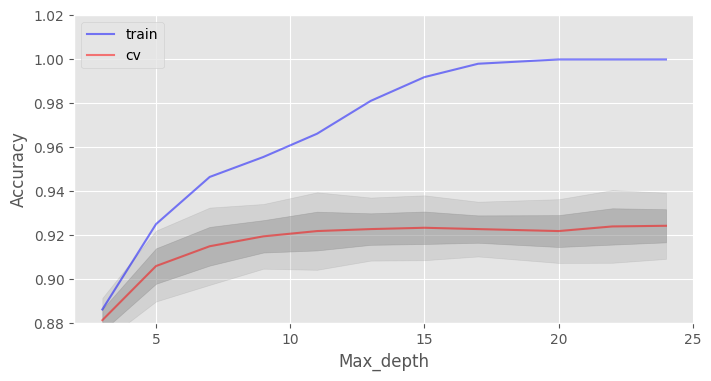

In [27]:
train_acc = []
test_acc = []
temp_train_acc = []
temp_test_acc = []
max_depth_grid = [3, 5, 7, 9, 11, 13, 15, 17, 20, 22, 24]

for max_depth in max_depth_grid:
    rfc = RandomForestClassifier(
        n_estimators=100, random_state=42, n_jobs=-1, oob_score=True, max_depth=max_depth)
    temp_train_acc = []
    temp_test_acc = []
    for train_index, test_index in skf.split(X, y):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y[train_index], y[test_index]
        rfc.fit(X_train, y_train)
        temp_train_acc.append(rfc.score(X_train, y_train))
        temp_test_acc.append(rfc.score(X_test, y_test))
    train_acc.append(temp_train_acc)
    test_acc.append(temp_test_acc)

train_acc, test_acc = np.asarray(train_acc), np.asarray(test_acc)
print("Best accuracy on CV is {:.2f}% with {} max_depth".format(max(test_acc.mean(axis=1))*100,
                                                                max_depth_grid[np.argmax(test_acc.mean(axis=1))]))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(max_depth_grid, train_acc.mean(axis=1),
        alpha=0.5, color='blue', label='train')
ax.plot(max_depth_grid, test_acc.mean(axis=1),
        alpha=0.5, color='red', label='cv')
ax.fill_between(max_depth_grid, test_acc.mean(axis=1) - test_acc.std(axis=1),
                test_acc.mean(axis=1) + test_acc.std(axis=1), color='#888888', alpha=0.4)
ax.fill_between(max_depth_grid, test_acc.mean(axis=1) - 2*test_acc.std(axis=1),
                test_acc.mean(axis=1) + 2*test_acc.std(axis=1), color='#888888', alpha=0.2)
ax.legend(loc='best')
ax.set_ylim([0.88, 1.02])
ax.set_ylabel("Accuracy")
ax.set_xlabel("Max_depth")
plt.show()

max_depth 在模型中起到了正则化的作用，过拟合现象有所缓解，模型准确率提高了一些。

另一个值得调整的重要参数是 min_samples_leaf，它也能起到正则化作用

Best accuracy on CV is 92.50% with 1 min_samples_leaf


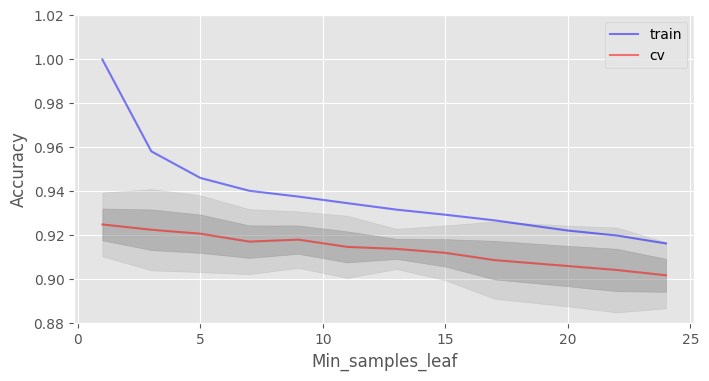

In [28]:
train_acc = []
test_acc = []
temp_train_acc = []
temp_test_acc = []
min_samples_leaf_grid = [1, 3, 5, 7, 9, 11, 13, 15, 17, 20, 22, 24]

for min_samples_leaf in min_samples_leaf_grid:
    rfc = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1,
                                 oob_score=True, min_samples_leaf=min_samples_leaf)
    temp_train_acc = []
    temp_test_acc = []
    for train_index, test_index in skf.split(X, y):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y[train_index], y[test_index]
        rfc.fit(X_train, y_train)
        temp_train_acc.append(rfc.score(X_train, y_train))
        temp_test_acc.append(rfc.score(X_test, y_test))
    train_acc.append(temp_train_acc)
    test_acc.append(temp_test_acc)

train_acc, test_acc = np.asarray(train_acc), np.asarray(test_acc)
print("Best accuracy on CV is {:.2f}% with {} min_samples_leaf".format(max(test_acc.mean(axis=1))*100,
                                                                       min_samples_leaf_grid[np.argmax(test_acc.mean(axis=1))]))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(min_samples_leaf_grid, train_acc.mean(
    axis=1), alpha=0.5, color='blue', label='train')
ax.plot(min_samples_leaf_grid, test_acc.mean(
    axis=1), alpha=0.5, color='red', label='cv')
ax.fill_between(min_samples_leaf_grid, test_acc.mean(axis=1) - test_acc.std(axis=1),
                test_acc.mean(axis=1) + test_acc.std(axis=1), color='#888888', alpha=0.4)
ax.fill_between(min_samples_leaf_grid, test_acc.mean(axis=1) - 2*test_acc.std(axis=1),
                test_acc.mean(axis=1) + 2*test_acc.std(axis=1), color='#888888', alpha=0.2)
ax.legend(loc='best')
ax.set_ylim([0.88, 1.02])
ax.set_ylabel("Accuracy")
ax.set_xlabel("Min_samples_leaf")
plt.show()

在这一情形下，验证集上的准确率没有提高，但当验证集的准确率保持 92% 以上时，过拟合的情况降低了 2%

下面考虑 max_features 这一参数。在分类问题中，默认特征为「所有特征数的平方根」

Best accuracy on CV is 92.50% with 4 max_features


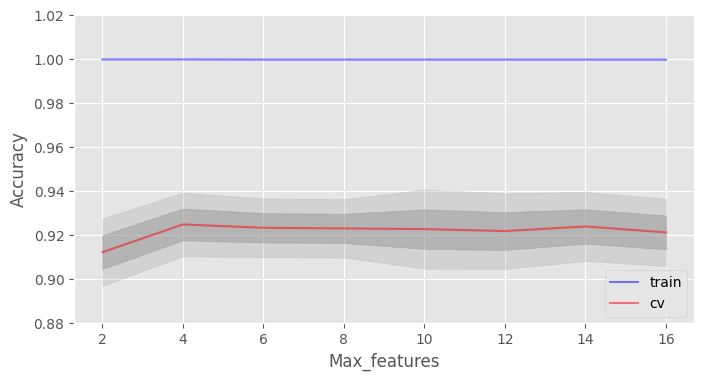

In [31]:
train_acc = []
test_acc = []
temp_train_acc = []
temp_test_acc = []
max_features_grid = [2, 4, 6, 8, 10, 12, 14, 16]

for max_features in max_features_grid:
    rfc = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1,
                                 oob_score=True, max_features=max_features)
    temp_train_acc = []
    temp_test_acc = []
    for train_index, test_index in skf.split(X, y):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y[train_index], y[test_index]
        rfc.fit(X_train, y_train)
        temp_train_acc.append(rfc.score(X_train, y_train))
        temp_test_acc.append(rfc.score(X_test, y_test))
    train_acc.append(temp_train_acc)
    test_acc.append(temp_test_acc)

train_acc, test_acc = np.asarray(train_acc), np.asarray(test_acc)
print("Best accuracy on CV is {:.2f}% with {} max_features".format(max(test_acc.mean(axis=1))*100,
                                                                   max_features_grid[np.argmax(test_acc.mean(axis=1))]))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(max_features_grid, train_acc.mean(axis=1),
        alpha=0.5, color='blue', label='train')
ax.plot(max_features_grid, test_acc.mean(axis=1),
        alpha=0.5, color='red', label='cv')
ax.fill_between(max_features_grid, test_acc.mean(axis=1) - test_acc.std(axis=1),
                test_acc.mean(axis=1) + test_acc.std(axis=1), color='#888888', alpha=0.4)
ax.fill_between(max_features_grid, test_acc.mean(axis=1) - 2*test_acc.std(axis=1),
                test_acc.mean(axis=1) + 2*test_acc.std(axis=1), color='#888888', alpha=0.2)
ax.legend(loc='best')
ax.set_ylim([0.88, 1.02])
ax.set_ylabel("Accuracy")
ax.set_xlabel("Max_features")
plt.show()

我们已经看到学习曲线如何随着基本参数的变化而变化。现在，直接使用 GridSearch() 来查找最佳参数

In [32]:
# 原实验搜索参数
parameters = {'max_features': [4, 7, 10, 13], 'min_samples_leaf': [
    1, 3, 5, 7], 'max_depth': [5, 10, 15, 20]}
# 为加速线上环境执行，优化搜索参数
# parameters = {'max_features': [10, 13], 'min_samples_leaf': [1, 3], 'max_depth': [5, 10]}
rfc = RandomForestClassifier(n_estimators=100, random_state=42,
                             n_jobs=-1, oob_score=True)
gcv = GridSearchCV(rfc, parameters, n_jobs=-1, cv=skf, verbose=1)
gcv.fit(X, y)
gcv.best_estimator_, gcv.best_score_

Fitting 5 folds for each of 64 candidates, totalling 320 fits


(RandomForestClassifier(max_depth=20, max_features=10, min_samples_leaf=3,
                        n_jobs=-1, oob_score=True, random_state=42),
 0.925596661128895)

调参之后，该模型的准确率达到了 92.5%。随机森林最重要的一点是它的准确率不会随着树的增加而下降，这意味着可以使用 10 棵树调整超参数，接着把树的数量从 10 增至 500 来提升准确率。

## 随机森林的方差和去相关 ##

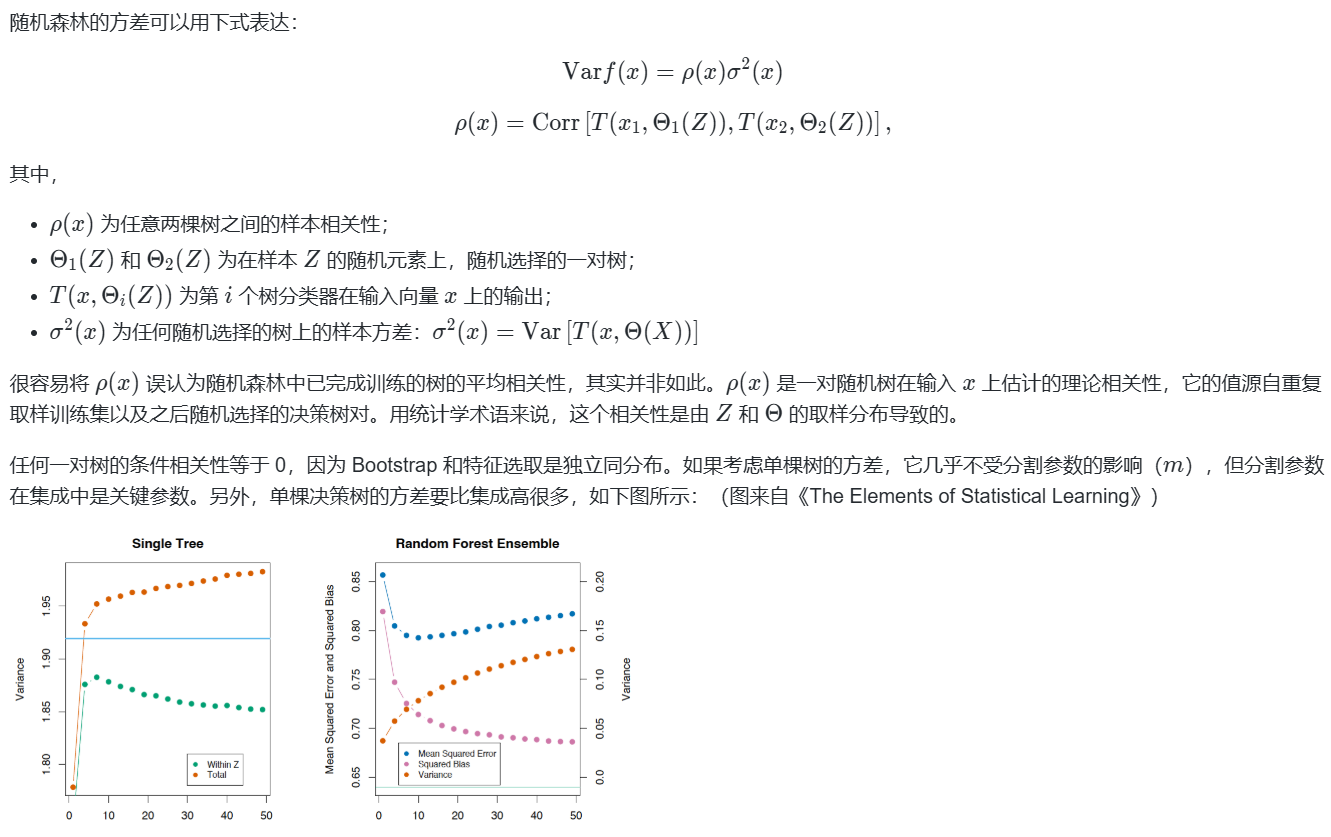
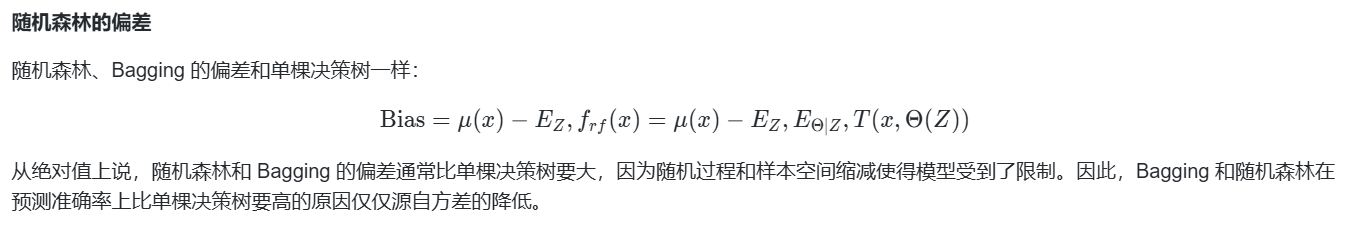

## 极端随机树 ## 
极端随机树（Extremely Randomized Trees）在节点分岔时应用了更多随机性。和随机森林一样，极端随机树使用一个随机特征子空间。然而，极端随机数并不搜寻最佳阈值，相反，它为每个可能的特征随机生成一个阈值，然后挑选最佳阈值对应的特征来分割节点，通过增加少量偏差来降低方差。

scikit-learn 库的 ExtraTreesClassifier() 和 ExtraTreesRegressor() 类实现了该方法。如果使用随机森林或梯度提升遇到了严重的过拟合，可以试试极端随机树。

## 随机森林和 k 近邻的相似性 ##

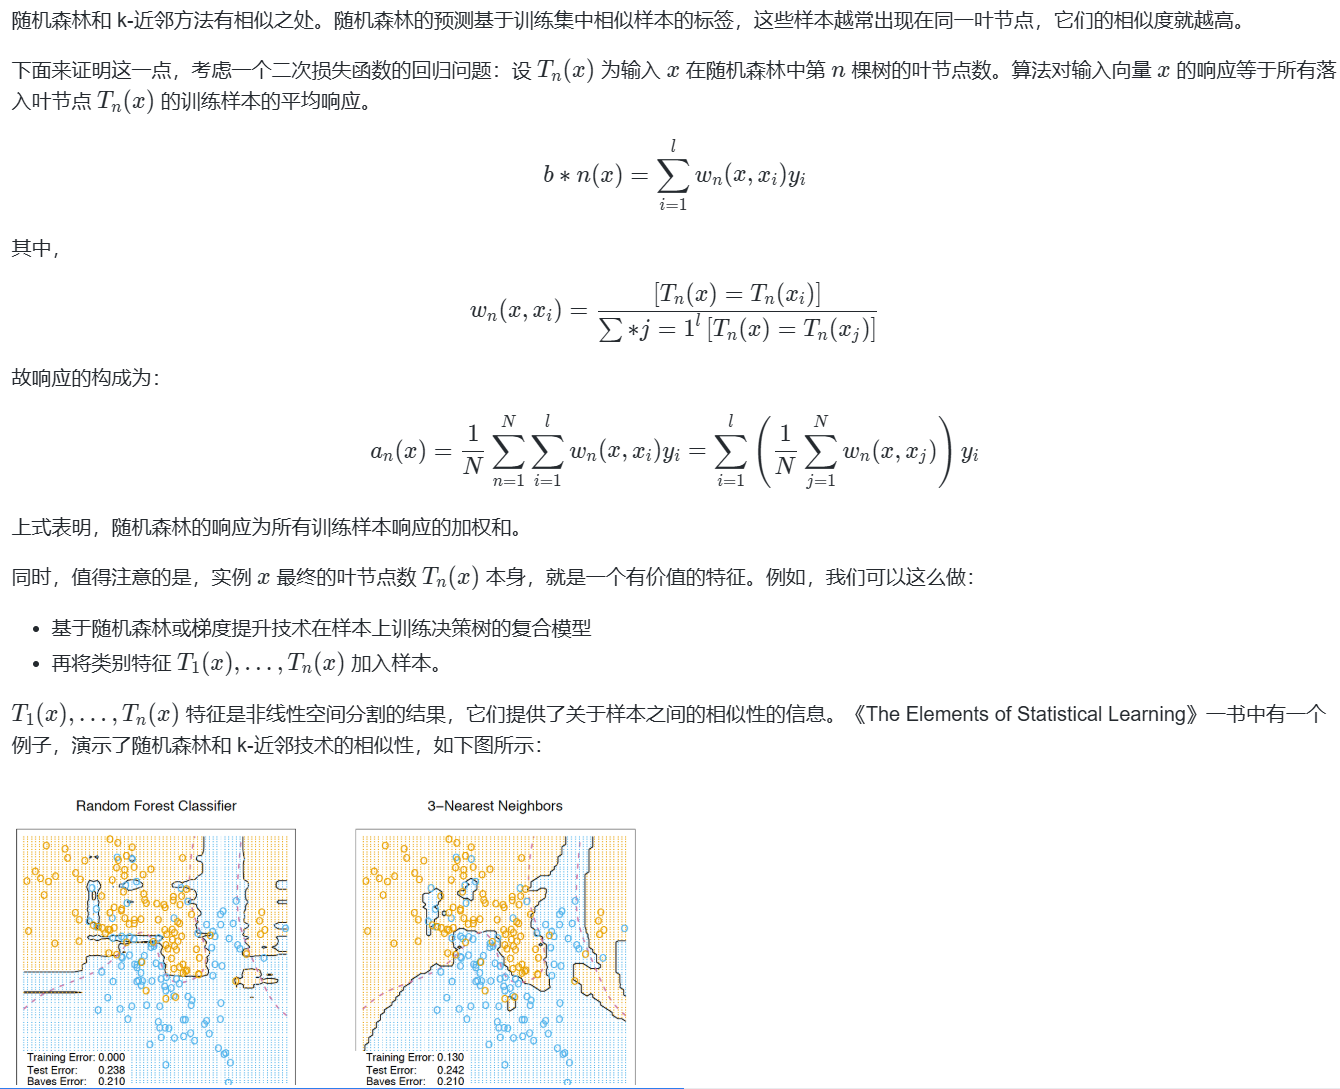

## 转换数据集为高维表示 ##
随机森林主要用于监督学习，不过也可以应用于无监督学习。使用 scikit-learn 的 RandomTreesEmbedding() 方法，可以将数据集转换为高维的稀疏表示，继而用于无监督学习中。

首先创建一些极端随机树，接着使用包含样本的叶节点索引作为新特征。例如，若第一个叶节点包含输入，就分配 1 为特征值，否则，分配 0。这被称为二进制编码（binary coding），我们可以通过增减树的数目和深度来控制特征数量和稀疏性。由于相近（邻居）的数据点倾向于落入同一叶节点，所以这一转换提供了一个隐式的对数据点密度的非参数估计。

## 随机森林的优势和劣势 ##
优势：

高预测准确率。在大多数问题上表现优于线性算法，准确率与 Boosting 相当；  
随机取样导致其对离散值的鲁棒性较好；  
随机选取子空间导致其对特征缩放及其他单调转换不敏感；  
不需要精细的参数调整。  
在具有大量特征和类别的数据集上很高效；  
既可处理连续值，也可处理离散值；  
不容易出现过拟合。在实践中，增加树的数量几乎总是能提升总体表现。不过，当树的数量增大到一定值后，学习曲线将趋于平稳；  
有理论方法可以估计特征的重要性；  
能够很好地处理数据缺失。即使有大部分的数据缺失现象，仍能保持较好的准确率；  
支持整个数据集及单棵树样本上的加权分类；  
决策树底层使用的相似性计算可以用于后续的聚类、离散值检测或兴趣数据表示；  
以上功能和性质可以扩展到未标注数据，以支持无监督聚类，数据可视化和离散值检测；  
易于并行化，伸缩性强。    
  

劣势：

相比单棵决策树，随机森林的输出更难解释；  
特征重要性估计没有形式化的 p 值；  
在数据稀疏时（比如，文本输入、词袋），表现不如线性模型好；  
和线性回归不同，随机森林无法外推。不过，这样也就不会因为离散值的存在导致极端值的出现；  
在某些问题上容易过拟合，特别是处理高噪声数据时；  
处理数量级不同的类别数据时，随机森林偏重数量级较高的数据，因为这能更明显的提高准确率；  
所得模型较大，需要大容量的 RAM 来支撑。  

## 特征的重要性 ##
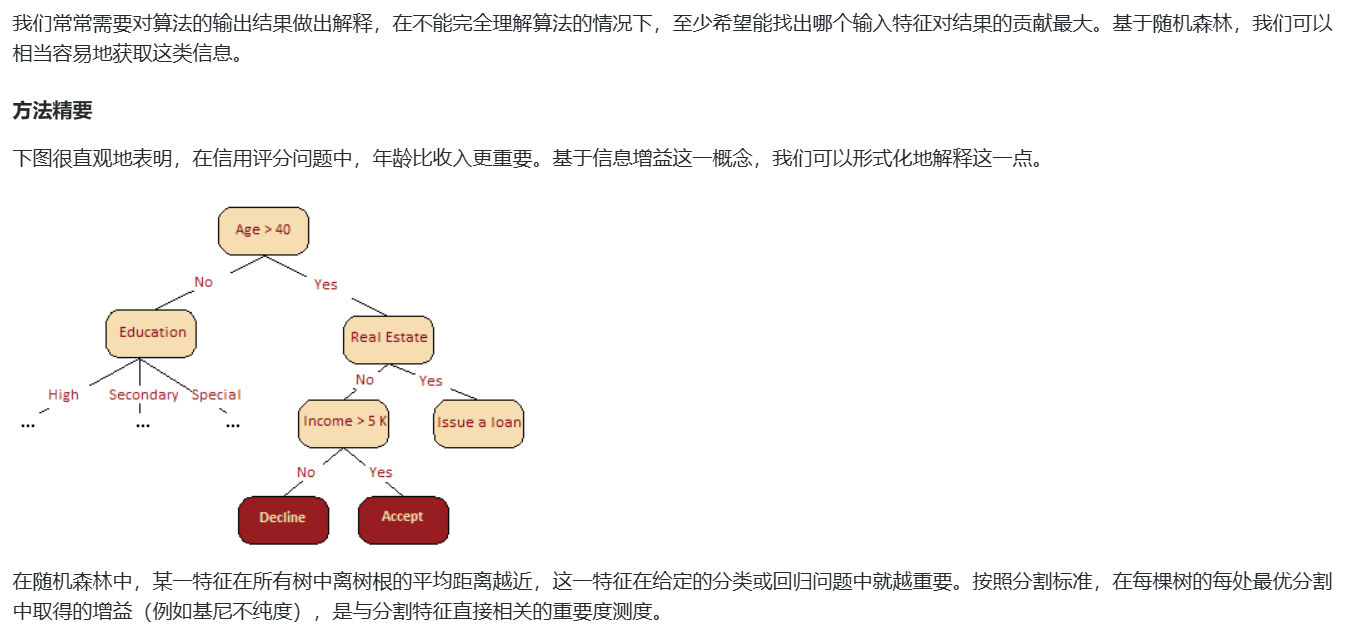
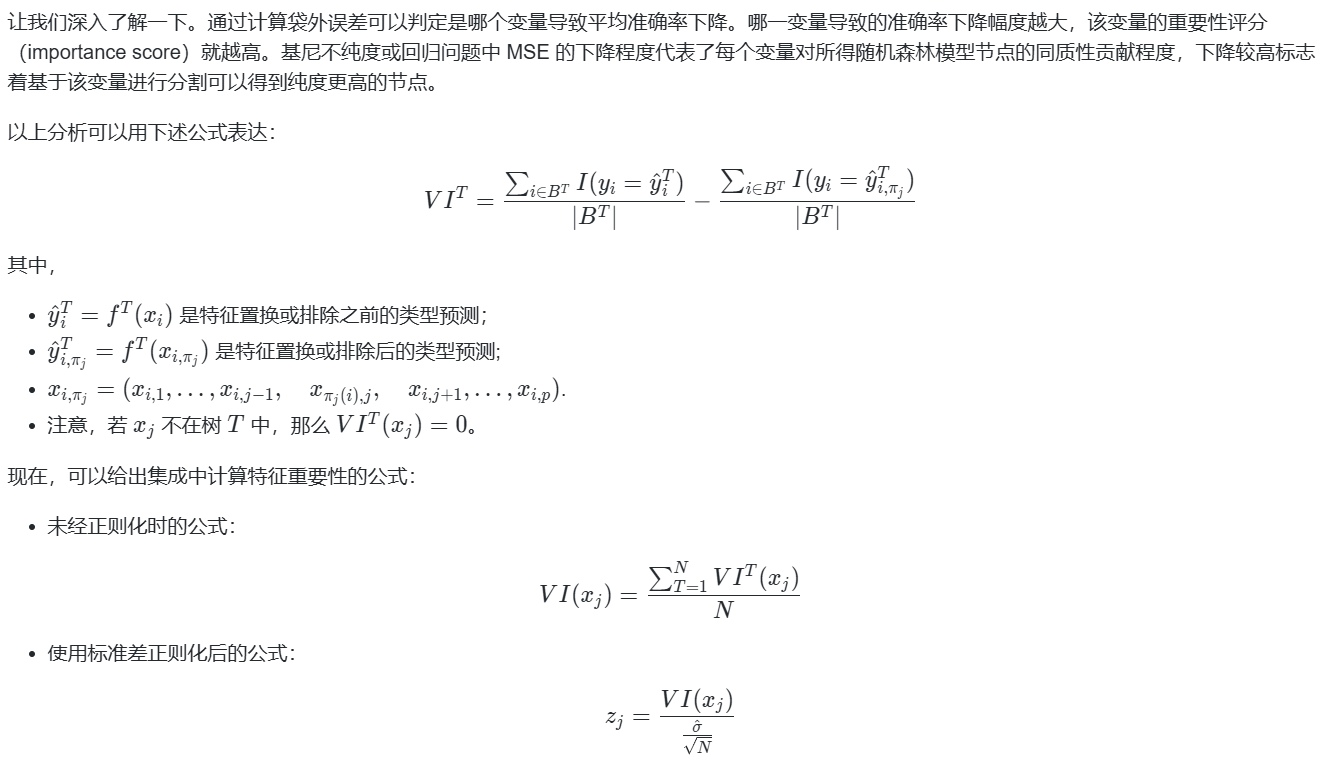

让我们考虑一个数据集，这数据集的内容是 Booking.com 和 TripAdvisor.com 上所列旅馆的一些信息，数据集的特征是不同类别（包括服务质量、房间状况、性价比等）的平均评分，目标变量为旅馆在网站上的总评分

Feature ranking:
1. Staff 0.183150 
2. Value for money 0.147704 
3. Shared space condition 0.128188 
4. Extra services 0.116819 
5. Customer Co-creation 0.105748 
6. General conditions & conveniences 0.088730 
7. Shared kitchen condition 0.074776 
8. Check-in and check-out 0.061881 
9. Hostel booking 0.053899 
10. Room condition 0.039105 


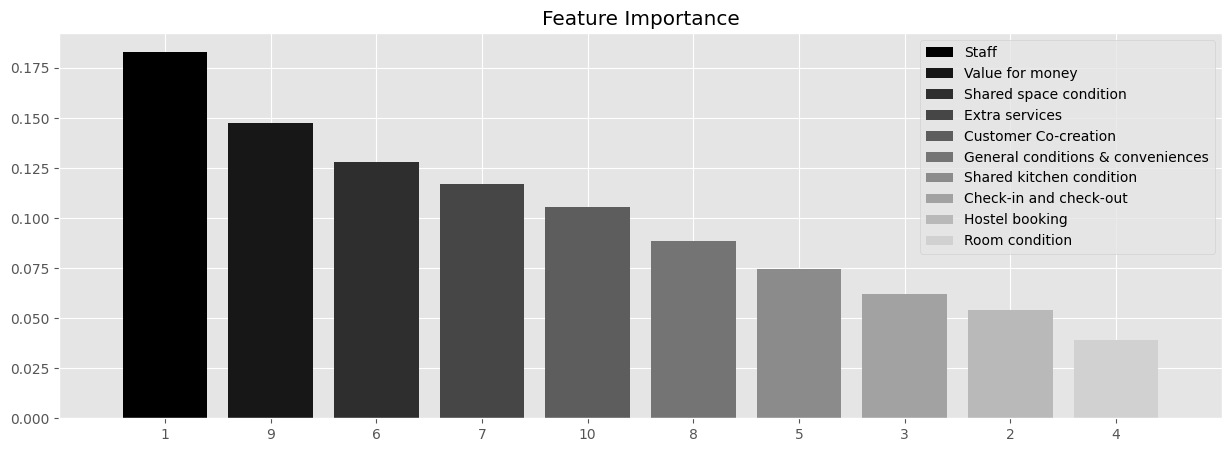

In [33]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

%matplotlib inline

hostel_data = pd.read_csv(
    "https://labfile.oss.aliyuncs.com/courses/1283/hostel_factors.csv")
features = {"f1": u"Staff",
            "f2": u"Hostel booking",
            "f3": u"Check-in and check-out",
            "f4": u"Room condition",
            "f5": u"Shared kitchen condition",
            "f6": u"Shared space condition",
            "f7": u"Extra services",
            "f8": u"General conditions & conveniences",
            "f9": u"Value for money",
            "f10": u"Customer Co-creation"}


forest = RandomForestRegressor(n_estimators=1000, max_features=10,
                               random_state=0)

forest.fit(hostel_data.drop(['hostel', 'rating'], axis=1),
           hostel_data['rating'])
importances = forest.feature_importances_

indices = np.argsort(importances)[::-1]

# Plot feature importances
num_to_plot = 10
feature_indices = [ind+1 for ind in indices[:num_to_plot]]

print("Feature ranking:")

for f in range(num_to_plot):
    print("%d. %s %f " % (f + 1,
                          features["f"+str(feature_indices[f])],
                          importances[indices[f]]))
plt.figure(figsize=(15, 5))
plt.title(u"Feature Importance")
bars = plt.bar(range(num_to_plot),
               importances[indices[:num_to_plot]],
               color=([str(i/float(num_to_plot+1))
                       for i in range(num_to_plot)]),
               align="center")
ticks = plt.xticks(range(num_to_plot),
                   feature_indices)
plt.xlim([-1, num_to_plot])
plt.legend(bars, [u''.join(features["f"+str(i)])
                  for i in feature_indices])
plt.show()

上图表明，消费者常常更关心服务人员素质（Staff）和性价比（Value for money)，这两个因子对最终评分的影响最大。然而，这两项特征和其他特征的差别不是非常大，因此排除任何特征都会导致模型准确率的下降。